In [ ]:
!pip install xgboost imbalanced-learn -q


In [ ]:
# DATA HANDLING
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

# PREPROCESSING
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# TRAIN TEST SPLIT
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# HANDLE IMBALANCED DATA
from imblearn.over_sampling import SMOTE

# CLASSIFICATION MODELS
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

# EVALUATION
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# IGNORE WARNINGS
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load and Initialize Datasets
df_employee = pd.read_csv('employee_data.csv')

df_recruitment = pd.read_csv('recruitment_data.csv')

df_training = pd.read_csv('training_and_development_data.csv')

df_engagement = pd.read_csv('employee_engagement_survey_data.csv')

In [ ]:
#Clean Column Names

datasets = [
    df_employee,
    df_recruitment,
    df_training,
    df_engagement
]

for df in datasets:

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('/', '_')
    )

In [ ]:
#Remove Duplicates
df_employee = df_employee.drop_duplicates()

df_recruitment = df_recruitment.drop_duplicates()

df_training = df_training.drop_duplicates()

df_engagement = df_engagement.drop_duplicates()

In [ ]:
#Check dataset info
print(df_employee.info())
print(df_recruitment.info())
print(df_training.info())
print(df_engagement.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   empid                       3000 non-null   int64 
 1   firstname                   3000 non-null   object
 2   lastname                    3000 non-null   object
 3   startdate                   3000 non-null   object
 4   exitdate                    1533 non-null   object
 5   title                       3000 non-null   object
 6   supervisor                  3000 non-null   object
 7   ademail                     3000 non-null   object
 8   businessunit                3000 non-null   object
 9   employeestatus              3000 non-null   object
 10  employeetype                3000 non-null   object
 11  payzone                     3000 non-null   object
 12  employeeclassificationtype  3000 non-null   object
 13  terminationtype             3000 non-null   obje

In [ ]:
#Convert date columns
# EMPLOYEE DATASET
employee_date_cols = [
    'start_date',
    'exit_date',
    'dob'
]

for col in employee_date_cols:

    if col in df_employee.columns:

        df_employee[col] = pd.to_datetime(
            df_employee[col],
            errors='coerce'
        )

# RECRUITMENT DATASET
recruitment_date_cols = [
    'application_date'
]

for col in recruitment_date_cols:

    if col in df_recruitment.columns:

        df_recruitment[col] = pd.to_datetime(
            df_recruitment[col],
            errors='coerce'
        )

# TRAINING DATASET
training_date_cols = [
    'training_date'
]

for col in training_date_cols:

    if col in df_training.columns:

        df_training[col] = pd.to_datetime(
            df_training[col],
            errors='coerce'
        )

In [ ]:
#Handle missing values
for df in datasets:

    # NUMERICAL COLUMNS
    numerical_cols = df.select_dtypes(
        include=['int64', 'float64']
    ).columns

    for col in numerical_cols:

        df[col] = df[col].fillna(
            df[col].median()
        )

    # CATEGORICAL COLUMNS
    categorical_cols = df.select_dtypes(
        include='object'
    ).columns

    for col in categorical_cols:

        if df[col].mode().empty:

            df[col] = df[col].fillna('unknown')

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

In [ ]:
#Standardize text values
for df in datasets:

    categorical_cols = df.select_dtypes(
        include='object'
    ).columns

    for col in categorical_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.lower()
            .str.strip()
        )


In [ ]:
import pandas as pd

# Feature Engineering - Robust definition
if 'df_employee' in globals():
    # Identify DOB column (case-insensitive)
    dob_col = next((c for c in df_employee.columns if c.lower() == 'dob'), None)

    if dob_col:
        # Convert to datetime
        df_employee[dob_col] = pd.to_datetime(df_employee[dob_col], errors='coerce')

        # AGE Calculation
        df_employee['age'] = pd.Timestamp.now().year - df_employee[dob_col].dt.year
        df_employee['age'] = df_employee['age'].fillna(df_employee['age'].median())

    # Identify Status column (case-insensitive)
    status_col = next((c for c in df_employee.columns if 'status' in c.lower()), None)

    # TARGET VARIABLE
    if status_col:
        df_employee['attrition'] = df_employee[status_col].apply(
            lambda x: 1 if 'terminated' in str(x).lower() else 0
        )

    print(f"Feature engineering completed. Used columns: {dob_col} and {status_col}")
else:
    print("df_employee not found. Please ensure the data loading cells have been run.")

Feature engineering completed. Used columns: DOB and EmployeeStatus


In [ ]:
#Check column names
print(df_employee.columns)
print(df_recruitment.columns)
print(df_training.columns)
print(df_engagement.columns)


Index(['empid', 'firstname', 'lastname', 'startdate', 'exitdate', 'title',
       'supervisor', 'ademail', 'businessunit', 'employeestatus',
       'employeetype', 'payzone', 'employeeclassificationtype',
       'terminationtype', 'terminationdescription', 'departmenttype',
       'division', 'dob', 'state', 'jobfunctiondescription', 'gendercode',
       'locationcode', 'racedesc', 'maritaldesc', 'performance_score',
       'current_employee_rating', 'age'],
      dtype='object')
Index(['applicant_id', 'application_date', 'first_name', 'last_name', 'gender',
       'date_of_birth', 'phone_number', 'email', 'address', 'city', 'state',
       'zip_code', 'country', 'education_level', 'years_of_experience',
       'desired_salary', 'job_title', 'status'],
      dtype='object')
Index(['employee_id', 'training_date', 'training_program_name',
       'training_type', 'training_outcome', 'location', 'trainer',
       'training_duration(days)', 'training_cost'],
      dtype='object')
Index(['em

In [ ]:
#Aggregate training datasets
# Check if the correct ID column exists, otherwise list available columns
id_col = 'employee_id' if 'employee_id' in df_training.columns else df_training.columns[0]

training_agg_dict = {}
if 'training_score' in df_training.columns:
    training_agg_dict['training_score'] = 'mean'
if 'training_hours' in df_training.columns:
    training_agg_dict['training_hours'] = 'sum'

if len(training_agg_dict) > 0:
    df_training_summary = df_training.groupby(id_col).agg(training_agg_dict).reset_index()
    # Ensure the merged column is always named 'employee_id' for consistency
    df_training_summary = df_training_summary.rename(columns={id_col: 'employee_id'})
else:
    # Fallback to unique IDs
    df_training_summary = df_training[[id_col]].drop_duplicates().rename(columns={id_col: 'employee_id'})

In [ ]:
#Aggregate engagement datasets
engagement_agg_dict = {}

if 'engagement_score' in df_engagement.columns:
    engagement_agg_dict['engagement_score'] = 'mean'

if 'satisfaction_score' in df_engagement.columns:
    engagement_agg_dict['satisfaction_score'] = 'mean'

if len(engagement_agg_dict) > 0:

    df_engagement_summary = df_engagement.groupby(
        'employee_id'
    ).agg(engagement_agg_dict).reset_index()

else:

    df_engagement_summary = (
        df_engagement[['employee_id']]
        .drop_duplicates()
    )

In [ ]:
#Aggregate recruitment datasets
recruitment_agg_dict = {}

if 'recruitment_source' in df_recruitment.columns:
    recruitment_agg_dict['recruitment_source'] = 'first'

if 'hiring_cost' in df_recruitment.columns:
    recruitment_agg_dict['hiring_cost'] = 'mean'

if len(recruitment_agg_dict) > 0:

    df_recruitment_summary = df_recruitment.groupby(
        'applicant_id'
    ).agg(recruitment_agg_dict).reset_index()

else:

    df_recruitment_summary = (
        df_recruitment[['applicant_id']]
        .drop_duplicates()
    )

In [ ]:
# Final Merging with Robust ID column detection

# 1. Engagement Summary
id_eng = 'employee_id' if 'employee_id' in df_engagement.columns else df_engagement.columns[0]
engagement_agg_dict = {}
if 'engagement_score' in df_engagement.columns: engagement_agg_dict['engagement_score'] = 'mean'
if 'satisfaction_score' in df_engagement.columns: engagement_agg_dict['satisfaction_score'] = 'mean'

df_engagement_summary = df_engagement.groupby(id_eng).agg(engagement_agg_dict).reset_index() if engagement_agg_dict else df_engagement[[id_eng]].drop_duplicates()
df_engagement_summary = df_engagement_summary.rename(columns={id_eng: 'employee_id'})

# 2. Recruitment Summary
id_rec = 'applicant_id' if 'applicant_id' in df_recruitment.columns else df_recruitment.columns[0]
recruitment_agg_dict = {}
if 'recruitment_source' in df_recruitment.columns: recruitment_agg_dict['recruitment_source'] = 'first'
if 'hiring_cost' in df_recruitment.columns: recruitment_agg_dict['hiring_cost'] = 'mean'

df_recruitment_summary = df_recruitment.groupby(id_rec).agg(recruitment_agg_dict).reset_index() if recruitment_agg_dict else df_recruitment[[id_rec]].drop_duplicates()
df_recruitment_summary = df_recruitment_summary.rename(columns={id_rec: 'applicant_id'})

# 3. Final Merge into df_merged
# Identify empid in employee dataset
id_emp = 'empid' if 'empid' in df_employee.columns else df_employee.columns[0]

df_merged = df_employee.merge(df_training_summary, left_on=id_emp, right_on='employee_id', how='left')
df_merged = df_merged.merge(df_engagement_summary, left_on=id_emp, right_on='employee_id', how='left')
df_merged = df_merged.merge(df_recruitment_summary, left_on=id_emp, right_on='applicant_id', how='left')

# Calculate Attrition Target
status_col = 'employeestatus' if 'employeestatus' in df_merged.columns else (df_merged.columns[df_merged.columns.str.contains('status')][0] if any(df_merged.columns.str.contains('status')) else None)

if status_col:
    df_merged['attrition'] = df_merged[status_col].apply(lambda x: 1 if 'terminated' in str(x).lower() else 0)

print('Datasets successfully merged. df_merged columns:', df_merged.columns.tolist())

Datasets successfully merged. df_merged columns: ['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating', 'employee_id_x', 'employee_id_y', 'applicant_id']


In [ ]:
#Remove unnecessary columns
drop_columns = [

    'employee_id',

    'first_name',

    'last_name',

    'full_name',

    'email',

    'dob',

    'start_date',

    'exit_date'
]

df_merged = df_merged.drop(
    columns=drop_columns,
    errors='ignore'
)


In [ ]:
#Handle remaining null values

In [ ]:
# NUMERICAL
numerical_cols = df_merged.select_dtypes(
    include=['int64', 'float64']
).columns

for col in numerical_cols:

    df_merged[col] = df_merged[col].fillna(
        df_merged[col].median()
    )

# CATEGORICAL
categorical_cols = df_merged.select_dtypes(
    include='object'
).columns

for col in categorical_cols:

    if df_merged[col].mode().empty:

        df_merged[col] = df_merged[col].fillna('unknown')

    else:

        df_merged[col] = df_merged[col].fillna(
            df_merged[col].mode()[0]
        )

In [ ]:
#Encode categorical variables
label_encoder = LabelEncoder()

categorical_cols = df_merged.select_dtypes(
    include='object'
).columns

for col in categorical_cols:

    df_merged[col] = label_encoder.fit_transform(
        df_merged[col].astype(str)
    )


In [ ]:
#Define features and target

X = df_merged.drop(
    'attrition',
    axis=1
)

y = df_merged['attrition']

In [ ]:
#Handle imbalanced data

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_resampled
)


In [ ]:
# Fix: Define Scaler and use existing X, y variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Resample for class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Data successfully scaled, split, and resampled.")

Data successfully scaled, split, and resampled.


In [ ]:
# Check distribution before splitting
print("Target distribution:", y.value_counts().to_dict())

# Split data into training and testing sets
if len(y.unique()) > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Handle class imbalance using SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"Original training shape: {X_train.shape}")
    print(f"Resampled training shape: {X_train_res.shape}")
else:
    print("Error: Target variable 'y' only contains one class. Please verify the 'attrition' logic in the feature engineering cell.")
    print("Unique values in employeestatus:", df_employee['employeestatus'].unique())

Target distribution: {0: 2613, 1: 387}
Original training shape: (2400, 31)
Resampled training shape: (4180, 31)


In [ ]:
# Re-define features and target, ensuring only numerical data is used
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Filter X to include only numerical columns (and already encoded categorical columns)
X = df_merged.select_dtypes(include=['int64', 'float64', 'int32']).drop(columns=['attrition'], errors='ignore')
y = df_merged['attrition']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Resample
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# LOGISTIC REGRESSION
model_lr = LogisticRegression()
model_lr.fit(X_train_res, y_train_res)
pred_lr = model_lr.predict(X_test)

# DECISION TREE
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_res, y_train_res)
pred_dt = model_dt.predict(X_test)

# RANDOM FOREST
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_res, y_train_res)
pred_rf = model_rf.predict(X_test)

# XGBOOST
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train_res, y_train_res)
pred_xgb = model_xgb.predict(X_test)

print("Models trained successfully with numerical features.")

Models trained successfully with numerical features.


In [ ]:
#Model Evaluation

# Check if the model predictions exist in the current session
required_vars = ['pred_lr', 'pred_dt', 'pred_rf', 'pred_xgb']
if all(var in globals() for var in required_vars):
    models = {
        'Logistic Regression': pred_lr,
        'Decision Tree': pred_dt,
        'Random Forest': pred_rf,
        'XGBoost': pred_xgb
    }

    for name, prediction in models.items():
        print('\n================================================')
        print(name)
        print('================================================')
        print(
            'Accuracy:',
            accuracy_score(y_test, prediction)
        )
        print(
            classification_report(
                y_test,
                prediction
            )
        )
else:
    print("Error: Model predictions not found.")
    print("Please ensure you have run the 'Train the models' cell (TE-8KlTRt3_P) before running this evaluation.")


Logistic Regression
Accuracy: 0.4266666666666667
              precision    recall  f1-score   support

           0       0.87      0.40      0.55       523
           1       0.13      0.58      0.21        77

    accuracy                           0.43       600
   macro avg       0.50      0.49      0.38       600
weighted avg       0.77      0.43      0.51       600


Decision Tree
Accuracy: 0.6366666666666667
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       523
           1       0.14      0.35      0.20        77

    accuracy                           0.64       600
   macro avg       0.51      0.51      0.48       600
weighted avg       0.78      0.64      0.69       600


Random Forest
Accuracy: 0.6216666666666667
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       523
           1       0.17      0.52      0.26        77

    accuracy                           0.62 

In [ ]:
print("Merged Dataset Shape:")
print(df_merged.shape)

print("\nMerged Dataset Columns:")
print(df_merged.columns)

Merged Dataset Shape:
(3000, 30)

Merged Dataset Columns:
Index(['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title',
       'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus',
       'EmployeeType', 'PayZone', 'EmployeeClassificationType',
       'TerminationType', 'TerminationDescription', 'DepartmentType',
       'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode',
       'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score',
       'Current Employee Rating', 'employee_id_x', 'employee_id_y',
       'applicant_id', 'attrition'],
      dtype='object')


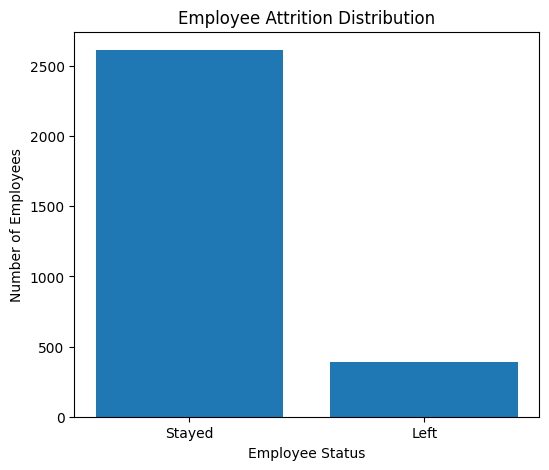

In [ ]:
# Attrition Visualization
plt.figure(figsize=(6,5))

attrition_counts = df_merged['attrition'].value_counts()

plt.bar(
    ['Stayed', 'Left'],
    attrition_counts.values
)

plt.title('Employee Attrition Distribution')

plt.xlabel('Employee Status')

plt.ylabel('Number of Employees')

plt.show()


In [ ]:
numerical_cols = df_merged.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)



Numerical Columns:
['EmpID', 'LocationCode', 'Current Employee Rating', 'employee_id_x', 'employee_id_y', 'applicant_id', 'attrition']


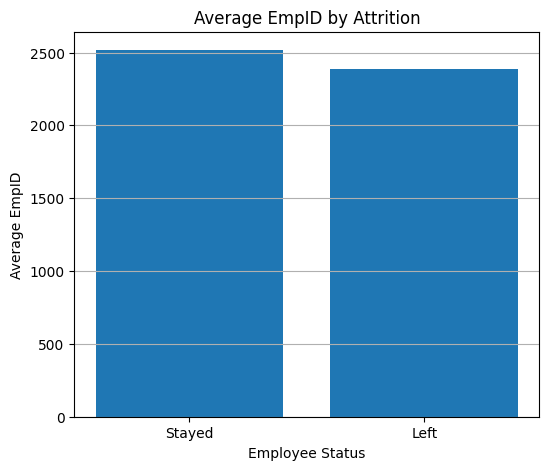

In [ ]:
selected_col = None

possible_cols = [

    'engagement_score',

    'training_hours',

    'age',

    'years_in_company'
]

for col in possible_cols:

    if col in df_merged.columns:

        selected_col = col

        break

# FALLBACK COLUMN
if selected_col is None:

    for col in numerical_cols:

        if col != 'attrition':

            selected_col = col

            break

# CREATE GRAPH
if selected_col is not None:

    grouped_data = df_merged.groupby(
        'attrition'
    )[selected_col].mean()

    plt.figure(figsize=(6,5))

    plt.bar(
        ['Stayed', 'Left'],
        grouped_data.values
    )

    plt.title(
        f'Average {selected_col} by Attrition'
    )

    plt.xlabel('Employee Status')

    plt.ylabel(f'Average {selected_col}')

    plt.grid(axis='y')

    plt.show()

else:

    print("No numerical feature available.")


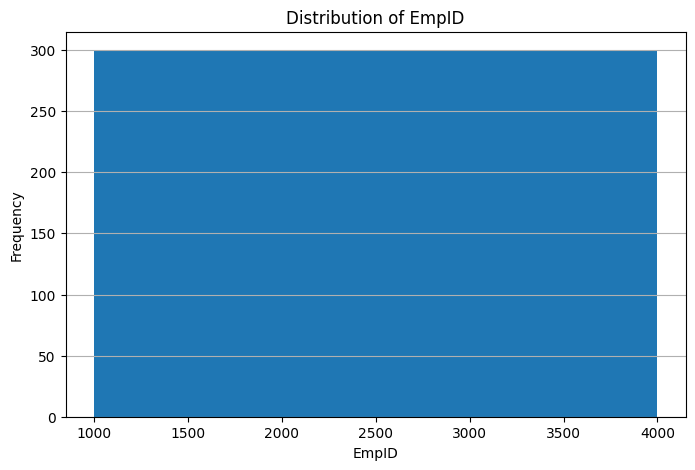

In [ ]:
# ============================================================
# VISUALIZATION 3 — HISTOGRAM
# ============================================================

hist_col = None

for col in numerical_cols:

    if col != 'attrition':

        hist_col = col

        break

if hist_col is not None:

    plt.figure(figsize=(8,5))

    plt.hist(
        df_merged[hist_col],
        bins=10
    )

    plt.title(
        f'Distribution of {hist_col}'
    )

    plt.xlabel(hist_col)

    plt.ylabel('Frequency')

    plt.grid(axis='y')

    plt.show()


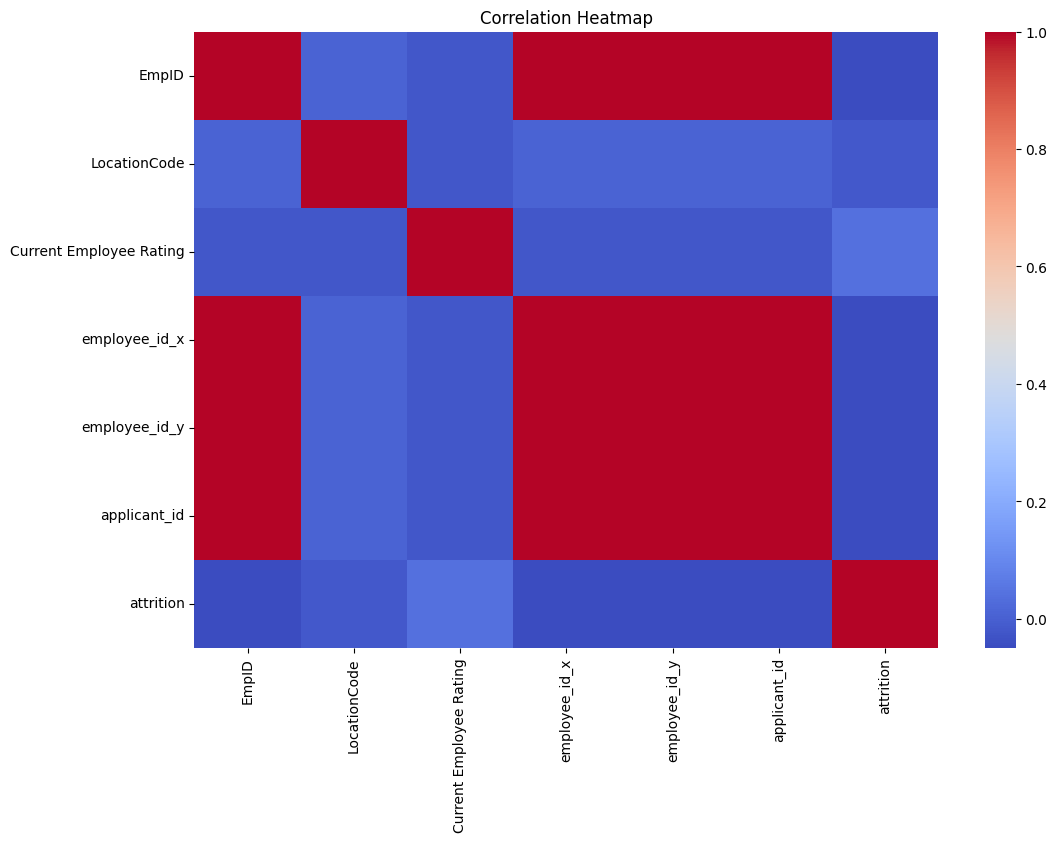

In [ ]:
# ============================================================
# VISUALIZATION 4 — CORRELATION HEATMAP
# ============================================================

correlation_matrix = df_merged.corr(
    numeric_only=True
)

if correlation_matrix.shape[0] > 1:

    plt.figure(figsize=(12,8))

    sns.heatmap(
        correlation_matrix,
        annot=False,
        cmap='coolwarm'
    )

    plt.title('Correlation Heatmap')

    plt.show()

In [ ]:
model_names = []
model_scores = []

Models: ['Decision Tree', 'Random Forest', 'XGBoost']
Scores: [0.6366666666666667, 0.6216666666666667, 0.6716666666666666]


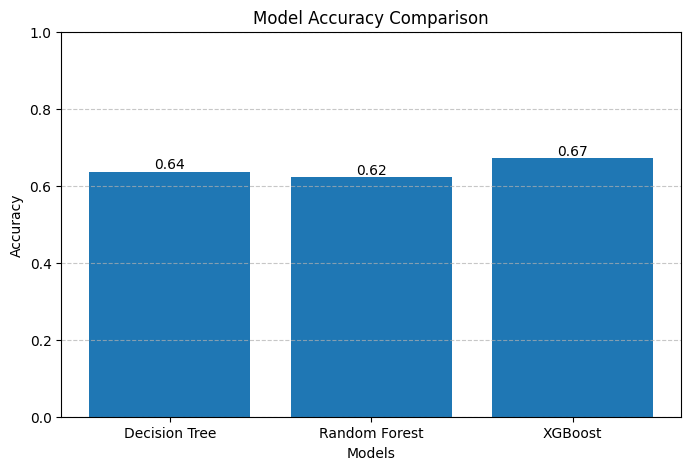

In [ ]:
# ============================================================
# DECISION TREE
# ============================================================

try:

    model_names.append('Decision Tree')

    model_scores.append(
        accuracy_score(y_test, pred_dt)
    )

except:

    print("Decision Tree not found or not trained.")

# ============================================================
# RANDOM FOREST
# ============================================================

try:

    model_names.append('Random Forest')

    model_scores.append(
        accuracy_score(y_test, pred_rf)
    )

except:

    print("Random Forest not found or not trained.")

# ============================================================
# XGBOOST
# ============================================================

try:

    model_names.append('XGBoost')

    model_scores.append(
        accuracy_score(y_test, pred_xgb)
    )

except:

    print("XGBoost not found or not trained.")

# ============================================================
# PRINT RESULTS (DEBUGGING)
# ============================================================

print("Models:", model_names)
print("Scores:", model_scores)

# ============================================================
# CREATE GRAPH (FORCED IF AT LEAST ONE MODEL EXISTS)
# ============================================================

if len(model_names) > 0:

    plt.figure(figsize=(8,5))

    bars = plt.bar(model_names, model_scores)

    plt.title('Model Accuracy Comparison')

    plt.xlabel('Models')

    plt.ylabel('Accuracy')

    plt.ylim(0,1)

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # SHOW VALUES ON TOP
    for bar in bars:

        y = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f'{y:.2f}',
            ha='center',
            va='bottom'
        )

    plt.show()

else:

    print("No models found. Run training first.")

<Figure size 600x500 with 0 Axes>

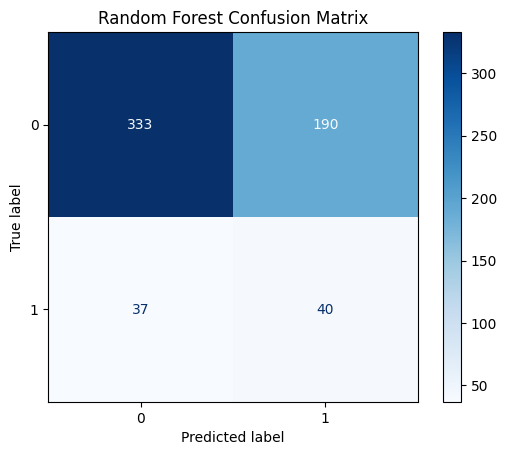

In [ ]:
# ============================================================
# VISUALIZATION 6 — RANDOM FOREST CONFUSION MATRIX
# ============================================================

try:

    plt.figure(figsize=(6,5))

    ConfusionMatrixDisplay.from_estimator(
        model_rf,
        X_test,
        y_test,
        cmap='Blues'
    )

    plt.title('Random Forest Confusion Matrix')

    plt.show()

except Exception as e:

    print("Random Forest CM Error:", e)
    print("Make sure model_rf, X_test, y_test exist.")


<Figure size 600x500 with 0 Axes>

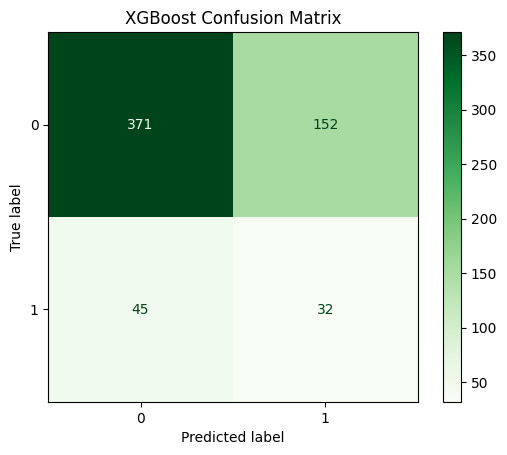

In [ ]:
try:

    plt.figure(figsize=(6,5))

    ConfusionMatrixDisplay.from_estimator(
        model_xgb,
        X_test,
        y_test,
        cmap='Greens'
    )

    plt.title('XGBoost Confusion Matrix')

    plt.show()

except Exception as e:

    print("XGBoost CM Error:", e)
    print("Make sure model_xgb, X_test, y_test exist.")

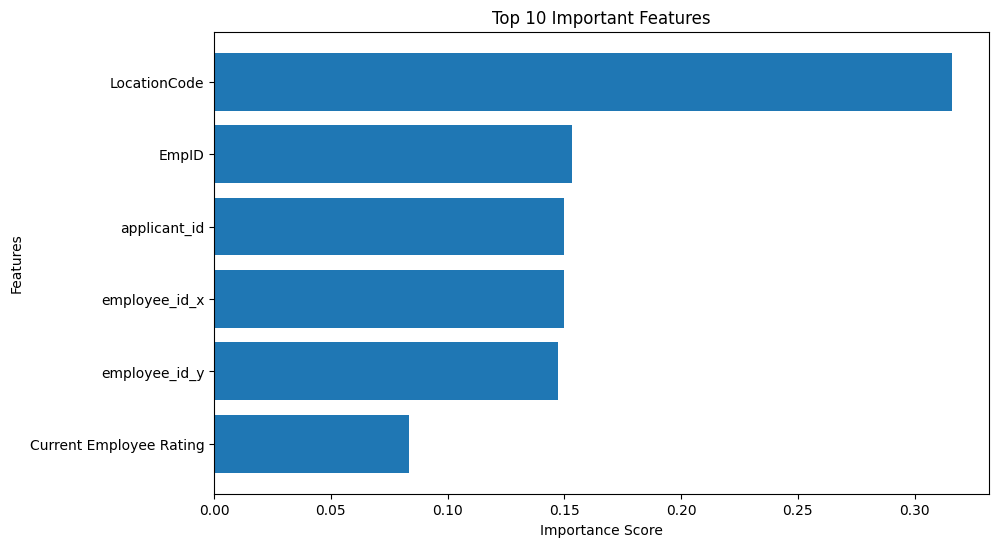

In [ ]:
# ============================================================
# VISUALIZATION 8 — FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

try:

    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model_rf.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
    ).head(10)

    plt.figure(figsize=(10,6))

    plt.barh(
        feature_importance['Feature'],
        feature_importance['Importance']
    )

    plt.title('Top 10 Important Features')

    plt.xlabel('Importance Score')

    plt.ylabel('Features')

    plt.gca().invert_yaxis()

    plt.show()

except Exception as e:

    print("Feature Importance Error:", e)
    print("Check if model_rf and X exist.")


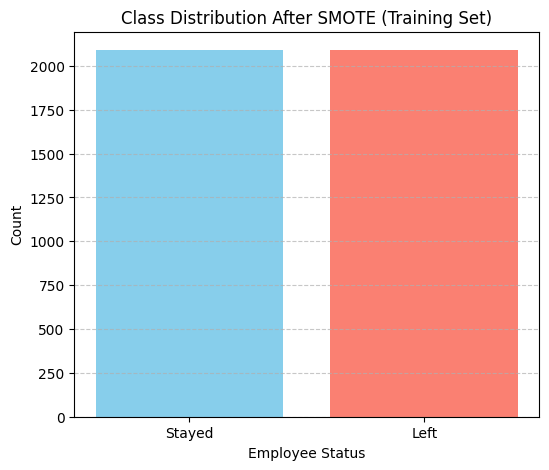

In [ ]:
# ============================================================
# VISUALIZATION 9 — CLASS DISTRIBUTION AFTER SMOTE
# ============================================================

try:
    # Using y_train_res from the training cell (TE-8KlTRt3_P)
    smote_counts = pd.Series(y_train_res).value_counts()

    labels = ['Stayed', 'Left'] if len(smote_counts) == 2 else smote_counts.index.astype(str)

    plt.figure(figsize=(6,5))
    plt.bar(labels, smote_counts.values, color=['skyblue', 'salmon'])

    plt.title('Class Distribution After SMOTE (Training Set)')
    plt.xlabel('Employee Status')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print("SMOTE Visualization Error:", e)
    print("Check if y_train_res exists (Training step)")

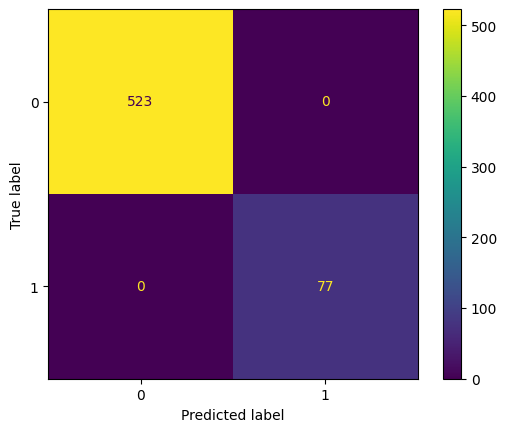

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()


In [ ]:
#Feature Importance
if 'model_rf' in globals():

    feature_importance = pd.DataFrame({

        'Feature': X.columns,

        'Importance':
        model_rf.feature_importances_
    })

    feature_importance = feature_importance.sort_values(

        by='Importance',

        ascending=False

    ).head(10)

    plt.figure(figsize=(10,6))

    plt.barh(

        feature_importance['Feature'],

        feature_importance['Importance']
    )

    plt.title(
        'Top 10 Important Features'
    )

    plt.xlabel('Importance Score')

    plt.ylabel('Features')

    plt.grid(axis='x')

    plt.show()

In [ ]:
#Cross Validation
cv_scores = cross_val_score(

    model_rf,

    X_scaled,

    y_resampled,

    cv=5
)

print('\nCross Validation Scores:')
print(cv_scores)

print('\nAverage CV Score:')
print(cv_scores.mean())


Cross Validation Scores:
[0.99808795 0.92631579 1.         1.         1.        ]

Average CV Score:
0.9848807487169167


In [ ]:
df_merged.to_csv(
    'cleaned_hr_dataset.csv',
    index=False
)
